In [2]:

import json
import re
import unicodedata
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import pandas as pd

In [6]:
CHART_KEYWORDS: Dict[str, Sequence[str]] = {
    "pie": ("pie", "camembert"),
    "hist": ("hist", "histogram", "distribution"),
    "scatter": ("scatter", "nuage"),
    "line": ("line", "courbe", "evolution", "tendance"),
    "bar": ("bar", "repartition", "nombre", "count"),
}

COMPARISON_PATTERNS: Sequence[Tuple[str, str]] = (
    (r">=", ">="),
    (r"<=", "<="),
    (r"!=", "!="),
    (r">", ">"),
    (r"<", "<"),
    (r"=", "=="),
)

@dataclass
class Intent:
    chart: str = "auto"
    group_by: Optional[str] = None
    x: Optional[str] = None
    y: Optional[str] = None
    filters: List[Dict[str, Any]] = field(default_factory=list)

GOOD_PROMPTS: List[str] = [
    "Bar chart du nombre d'entités par ForceIdentifier",
    "Pie chart de la répartition par DamageState",
    "Histogramme de SimTime",
    "Scatter de Spatial_static_WorldLocation_x vs Spatial_static_WorldLocation_y",
    "Line chart du nombre de lignes par SimTime",
    "Répartition par EntityType avec HasAmmunitionSupplyCap = true",
    "Nombre de lignes par HlaObjectType avec IsConcealed = false",
    "Bar chart de DamageState où ForceIdentifier = 2",
]

GOOD_PROMPTS

["Bar chart du nombre d'entités par ForceIdentifier",
 'Pie chart de la répartition par DamageState',
 'Histogramme de SimTime',
 'Scatter de Spatial_static_WorldLocation_x vs Spatial_static_WorldLocation_y',
 'Line chart du nombre de lignes par SimTime',
 'Répartition par EntityType avec HasAmmunitionSupplyCap = true',
 'Nombre de lignes par HlaObjectType avec IsConcealed = false',
 'Bar chart de DamageState où ForceIdentifier = 2']

In [7]:
def strip_accents(text: str) -> str:
    normalized = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in normalized if not unicodedata.combining(ch))


def normalize_text(text: str) -> str:
    return strip_accents(text).lower().strip()


def tokenize(text: str) -> List[str]:
    return re.findall(r"[a-z0-9_]+", normalize_text(text))


def flatten_record(obj: Dict[str, Any], parent: str = "") -> Dict[str, Any]:
    flat: Dict[str, Any] = {}
    for key, value in obj.items():
        full_key = f"{parent}_{key}" if parent else key
        if isinstance(value, dict):
            flat.update(flatten_record(value, full_key))
        elif isinstance(value, list):
            continue
        else:
            flat[full_key] = value
    return flat


def load_df(file_path: str) -> pd.DataFrame:
    path = Path(file_path)
    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix in {".json", ".log"}:
        records: List[Dict[str, Any]] = []
        with path.open("r", encoding="utf-8") as handle:
            for line in handle:
                payload = line.strip()
                if not payload:
                    continue
                records.append(flatten_record(json.loads(payload)))
        return pd.DataFrame(records)

    raise ValueError(f"Format non supporté: {suffix}")

In [8]:
def infer_chart(prompt: str) -> str:
    p = normalize_text(prompt)
    for chart, words in CHART_KEYWORDS.items():
        if any(word in p for word in words):
            return chart
    return "auto"


def column_candidates(prompt: str, columns: Iterable[str]) -> List[str]:
    prompt_norm = normalize_text(prompt)
    prompt_tokens = set(tokenize(prompt))
    scored: List[Tuple[int, int, str]] = []

    for col in columns:
        col_norm = normalize_text(col)
        col_tokens = set(tokenize(col))
        if col_norm in prompt_norm:
            pos = prompt_norm.find(col_norm)
            scored.append((1000, -pos, col))
            continue

        overlap = len(prompt_tokens & col_tokens)
        if overlap > 0:
            scored.append((overlap, 0, col))

    scored.sort(reverse=True)
    return [col for _, _, col in scored]


def find_explicit_column(prompt: str, columns: Sequence[str]) -> Optional[str]:
    candidates = column_candidates(prompt, columns)
    return candidates[0] if candidates else None


def parse_scalar(value_text: str) -> Any:
    raw = value_text.strip().strip("'\"")
    low = normalize_text(raw)
    if low in {"true", "vrai", "yes"}:
        return True
    if low in {"false", "faux", "no"}:
        return False
    if re.fullmatch(r"-?\d+", raw):
        return int(raw)
    if re.fullmatch(r"-?\d+\.\d+", raw):
        return float(raw)
    return raw


def parse_filters(prompt: str, df: pd.DataFrame) -> List[Dict[str, Any]]:
    filters: List[Dict[str, Any]] = []
    columns = df.columns.tolist()

    for column in columns:
        col_re = re.escape(column)

        for symbol_regex, op in COMPARISON_PATTERNS:
            pattern = rf"\b{col_re}\b\s*{symbol_regex}\s*([^,;]+)"
            for match in re.finditer(pattern, prompt, flags=re.IGNORECASE):
                value = parse_scalar(match.group(1))
                filters.append({"column": column, "op": op, "value": value})

        bool_series = df[column].dropna()
        if not bool_series.empty and bool_series.map(type).eq(bool).all():
            with_pattern = rf"(?:avec|ayant|where)\s+{col_re}\b"
            without_pattern = rf"(?:sans|without)\s+{col_re}\b"
            if re.search(with_pattern, prompt, flags=re.IGNORECASE):
                filters.append({"column": column, "op": "==", "value": True})
            if re.search(without_pattern, prompt, flags=re.IGNORECASE):
                filters.append({"column": column, "op": "==", "value": False})

    unique: List[Dict[str, Any]] = []
    seen = set()
    for flt in filters:
        key = (flt["column"], flt["op"], str(flt["value"]))
        if key not in seen:
            seen.add(key)
            unique.append(flt)
    return unique


def extract_axes(prompt: str, df: pd.DataFrame) -> Tuple[Optional[str], Optional[str]]:
    columns = df.columns.tolist()

    parts = re.split(r"\bvs\b|\bversus\b", prompt, flags=re.IGNORECASE)
    if len(parts) == 2:
        return find_explicit_column(parts[0], columns), find_explicit_column(parts[1], columns)

    x_match = re.search(r"(?:x|axe x)\s*[:=]\s*([A-Za-z0-9_\.]+)", prompt, flags=re.IGNORECASE)
    y_match = re.search(r"(?:y|axe y)\s*[:=]\s*([A-Za-z0-9_\.]+)", prompt, flags=re.IGNORECASE)
    x_col = find_explicit_column(x_match.group(1), columns) if x_match else None
    y_col = find_explicit_column(y_match.group(1), columns) if y_match else None
    return x_col, y_col


def extract_intent(prompt: str, df: pd.DataFrame) -> Intent:
    intent = Intent(chart=infer_chart(prompt))
    columns = df.columns.tolist()

    intent.x, intent.y = extract_axes(prompt, df)

    mentioned = column_candidates(prompt, columns)
    if intent.x in mentioned:
        mentioned.remove(intent.x)
    if intent.y in mentioned:
        mentioned.remove(intent.y)

    if mentioned:
        intent.group_by = mentioned[0]

    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    if intent.chart in {"scatter", "line"} and (intent.x is None or intent.y is None):
        if len(numeric_cols) >= 2:
            intent.x = intent.x or numeric_cols[0]
            intent.y = intent.y or numeric_cols[1]

    if intent.chart == "hist" and intent.x is None:
        intent.x = numeric_cols[0] if numeric_cols else None

    if intent.chart == "line" and intent.x is None and numeric_cols:
        intent.x = numeric_cols[0]

    intent.filters = parse_filters(prompt, df)
    return intent

In [9]:
def apply_filters(df: pd.DataFrame, filters: List[Dict[str, Any]]) -> pd.DataFrame:
    out = df.copy()
    for flt in filters:
        col, op, val = flt["column"], flt["op"], flt["value"]
        if col not in out.columns:
            continue

        if op == "==":
            out = out[out[col] == val]
        elif op == "!=":
            out = out[out[col] != val]
        elif op in {">", ">=", "<", "<="}:
            series = pd.to_numeric(out[col], errors="coerce")
            num_val = pd.to_numeric(pd.Series([val]), errors="coerce").iloc[0]
            if pd.isna(num_val):
                continue
            if op == ">":
                out = out[series > num_val]
            elif op == ">=":
                out = out[series >= num_val]
            elif op == "<":
                out = out[series < num_val]
            elif op == "<=":
                out = out[series <= num_val]
    return out


def plot_from_intent(df: pd.DataFrame, intent: Intent, prompt: str):
    data = apply_filters(df, intent.filters)
    if data.empty:
        raise ValueError("Aucune donnée après application des filtres.")

    fig, ax = plt.subplots(figsize=(10, 6))

    if intent.chart == "pie" and intent.group_by and intent.group_by in data.columns:
        counts = data[intent.group_by].astype(str).value_counts().head(12)
        ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)
        ax.set_title(prompt)
        return fig

    if intent.chart == "hist" and intent.x and intent.x in data.columns:
        vals = pd.to_numeric(data[intent.x], errors="coerce").dropna()
        ax.hist(vals, bins=20)
        ax.set_xlabel(intent.x)
        ax.set_ylabel("Count")
        ax.set_title(prompt)
        return fig

    if intent.chart == "scatter" and intent.x and intent.y:
        if intent.x in data.columns and intent.y in data.columns:
            xs = pd.to_numeric(data[intent.x], errors="coerce")
            ys = pd.to_numeric(data[intent.y], errors="coerce")
            valid = xs.notna() & ys.notna()
            ax.scatter(xs[valid], ys[valid], alpha=0.7)
            ax.set_xlabel(intent.x)
            ax.set_ylabel(intent.y)
            ax.set_title(prompt)
            return fig

    if intent.chart == "line" and intent.x and intent.x in data.columns:
        if intent.y and intent.y in data.columns:
            ys = pd.to_numeric(data[intent.y], errors="coerce")
            ax.plot(data[intent.x], ys, marker="o")
            ax.set_ylabel(intent.y)
        else:
            counts = data.groupby(intent.x).size().reset_index(name="count")
            ax.plot(counts[intent.x], counts["count"], marker="o")
            ax.set_ylabel("Count")
        ax.set_xlabel(intent.x)
        ax.set_title(prompt)
        return fig

    if intent.group_by and intent.group_by in data.columns:
        counts = data[intent.group_by].astype(str).value_counts(dropna=False).head(20)
        ax.bar(counts.index, counts.values)
        ax.set_xlabel(intent.group_by)
        ax.set_ylabel("Count")
        ax.set_title(prompt)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        return fig

    ax.bar(["count"], [len(data)])
    ax.set_title(prompt)
    ax.set_ylabel("Count")
    return fig


def visualize_from_df(df: pd.DataFrame, prompt: str):
    intent = extract_intent(prompt, df)
    fig = plot_from_intent(df, intent, prompt)
    return fig, intent

Intent(chart='pie', group_by='DamageState', x=None, y=None, filters=[])


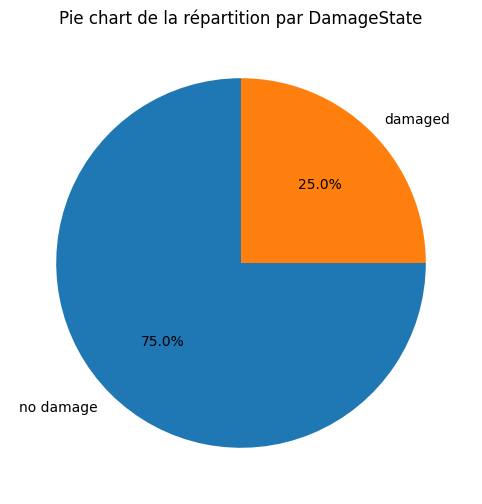

In [13]:
df = load_df("data/lidata.log")
prompt = "Pie chart de la répartition par DamageState"
fig, intent = visualize_from_df(df, prompt)
print(intent)


Intent(chart='scatter', group_by=None, x='Spatial_static_WorldLocation_x', y='Spatial_static_WorldLocation_y', filters=[])


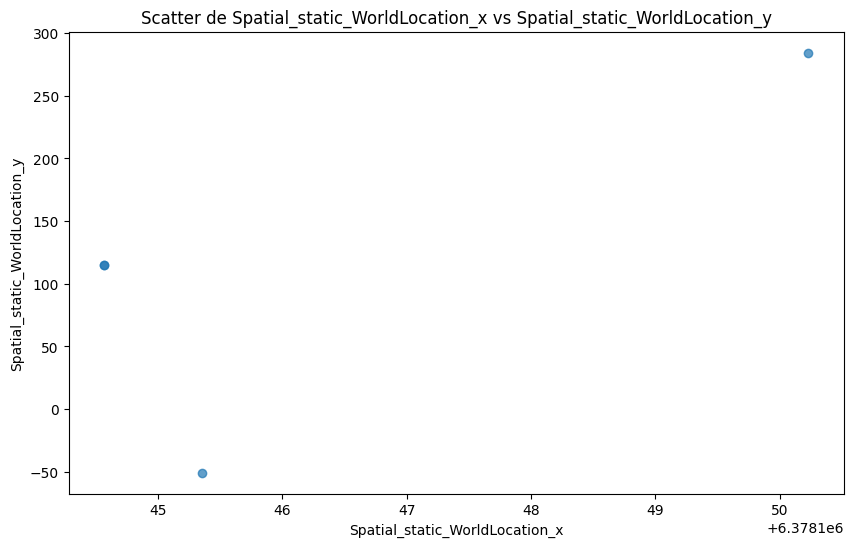

In [12]:
prompt = "Scatter de Spatial_static_WorldLocation_x vs Spatial_static_WorldLocation_y"
fig, intent = visualize_from_df(df, prompt)
print(intent)


Intent(chart='bar', group_by='HasAmmunitionSupplyCap', x=None, y=None, filters=[{'column': 'HasAmmunitionSupplyCap', 'op': '==', 'value': True}])


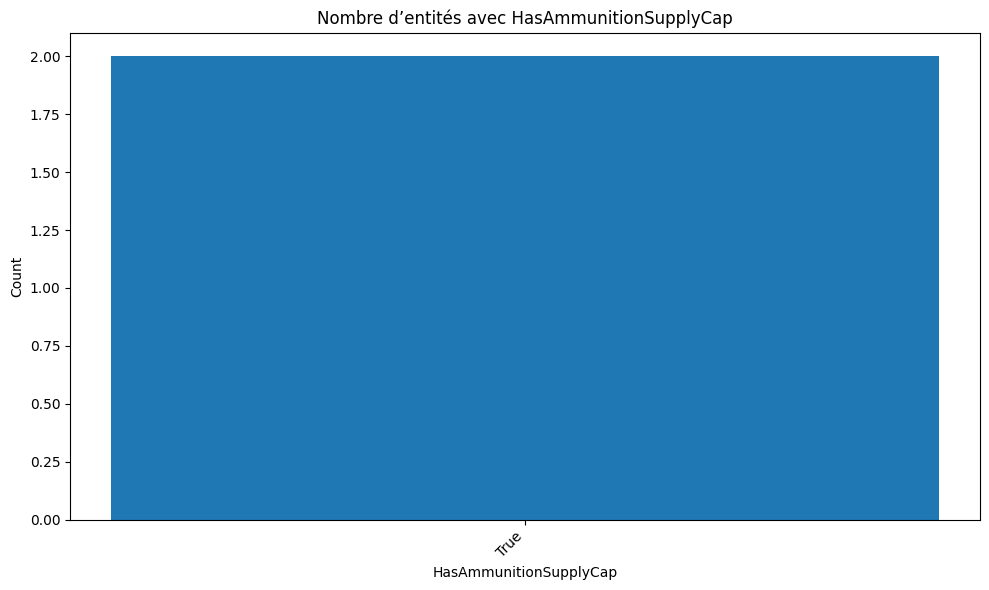

In [15]:
prompt = "Nombre d’entités avec HasAmmunitionSupplyCap"
fig, intent = visualize_from_df(df, prompt)
print(intent)


Intent(chart='bar', group_by='ForceIdentifier', x=None, y=None, filters=[])


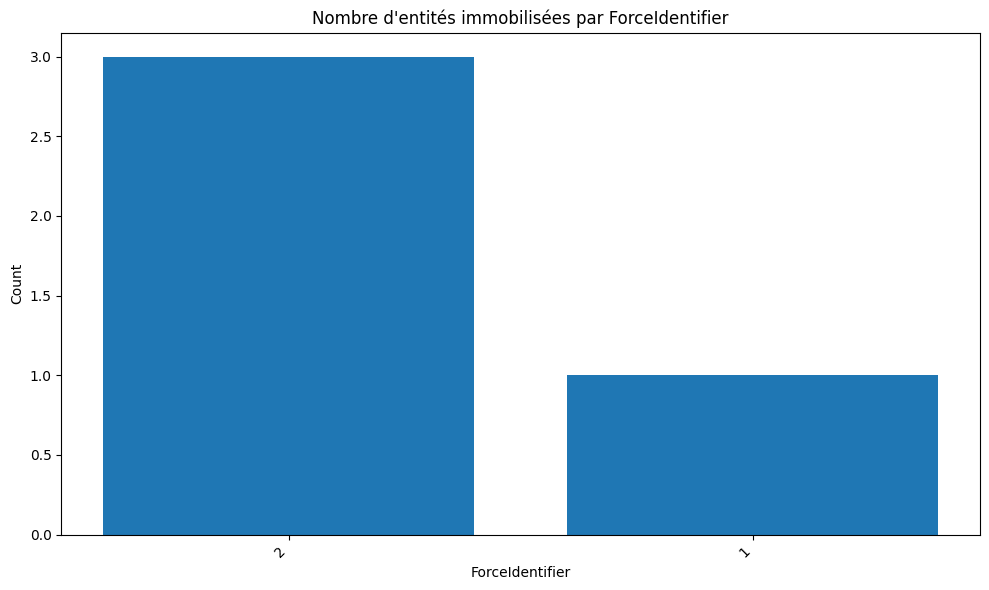

In [17]:
prompt = "Nombre d'entités immobilisées par ForceIdentifier"
fig, intent = visualize_from_df(df, prompt)
print(intent)